In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv("C:\\Users\\mdsha\\Downloads\\Scores.csv", sep=';', on_bad_lines='skip')
print("Data loaded successfully!")
print(f"Shape: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"\nColumn names and types:\n{data.dtypes}")
print(f"\nFirst few rows:\n{data.head()}")

Data loaded successfully!
Shape: 972 rows, 6 columns

Column names and types:
Unnamed: 0                      int64
student_id                     object
gender                         object
parental.level.of.education    object
subject                        object
score                          object
dtype: object

First few rows:
   Unnamed: 0 student_id  gender parental.level.of.education   subject score
0           1     id_001  female                 high school      math    23
1           2     id_001  female                 high school  language    40
2           3     id_002  female                 high school      math    68
3           4     id_002  female                 high school  language  80,5
4           5     id_003    male                 high school      math    82


In [8]:

print("\n" + "="*60)
print("STEP 1: DATA VALIDATION & RESHAPING")
print("="*60)

data['score'] = data['score'].astype(str).str.replace(',', '.').astype(float)

print("\nInitial shape (long format):", data.shape)
print("\nMissing values per variable:")
print(data.isnull().sum())

print("\nScore ranges:")
print(f"  Score: min={data['score'].min()}, max={data['score'].max()}")

out_of_range = ((data['score'] < 0) | (data['score'] > 100)).sum()
print(f"\nImpossible values (scores outside 0-100): {out_of_range} values")

print(f"Duplicate rows: {data.duplicated().sum()}")

data_pivot = data.pivot_table(
    index=['student_id', 'gender', 'parental.level.of.education'],
    columns='subject',
    values='score',
    aggfunc='first'
).reset_index()

print(f"\nReshaped data (wide format) - Shape: {data_pivot.shape}")
print(f"\nColumn names after reshape:\n{data_pivot.columns.tolist()}")
print(f"\nFirst few rows:")
print(data_pivot.head())


STEP 1: DATA VALIDATION & RESHAPING

Initial shape (long format): (972, 6)

Missing values per variable:
Unnamed: 0                     0
student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64

Score ranges:
  Score: min=19.5, max=100.0

Impossible values (scores outside 0-100): 0 values
Duplicate rows: 0

Reshaped data (wide format) - Shape: (486, 5)

Column names after reshape:
['student_id', 'gender', 'parental.level.of.education', 'language', 'math']

First few rows:
subject student_id  gender parental.level.of.education  language  math
0           id_001  female                 high school      40.0  23.0
1           id_002  female                 high school      80.5  68.0
2           id_003    male                 high school      81.0  82.0
3           id_004  female                 high school      60.5  58.0
4           id_005  female                 hi

In [9]:
print("\n" + "="*60)
print("STEP 2: DATA CLEANING & PREPARATION")
print("="*60)

data = data_pivot.copy()

print("\nAll columns:")
print(data.columns.tolist())

col_lower = {col.lower(): col for col in data.columns}
print(f"\nColumn name mapping:")
for orig_col, mapped_col in col_lower.items():
    print(f"  {orig_col} -> {mapped_col}")

math_col = next((col for col in data.columns if 'math' in col.lower()), None)
lang_col = next((col for col in data.columns if 'lang' in col.lower()), None)
gender_col = next((col for col in data.columns if 'gender' in col.lower()), None)
parental_col = next((col for col in data.columns if 'parental' in col.lower() or 'education' in col.lower()), None)

print(f"\nIdentified columns:")
print(f"  Mathematics: {math_col}")
print(f"  Language: {lang_col}")
print(f"  Gender: {gender_col}")
print(f"  Parental Education: {parental_col}")

if all([math_col, lang_col, gender_col, parental_col]):
    data_clean = data[[math_col, lang_col, gender_col, parental_col]].dropna()
    print(f"\nRows removed due to missing values: {len(data) - len(data_clean)}")
    data = data_clean.reset_index(drop=True)
    
    data.rename(columns={
        math_col: 'Mathematics',
        lang_col: 'Language',
        gender_col: 'Gender',
        parental_col: 'ParentalEducation'
    }, inplace=True)
    
    print(f"\nData shape after cleaning: {data.shape}")
    print(f"\nFirst few rows:")
    print(data.head())
else:
    print("\nWarning: Not all expected columns found. Proceeding with available data.")


STEP 2: DATA CLEANING & PREPARATION

All columns:
['student_id', 'gender', 'parental.level.of.education', 'language', 'math']

Column name mapping:
  student_id -> student_id
  gender -> gender
  parental.level.of.education -> parental.level.of.education
  language -> language
  math -> math

Identified columns:
  Mathematics: math
  Language: language
  Gender: gender
  Parental Education: parental.level.of.education

Rows removed due to missing values: 0

Data shape after cleaning: (486, 4)

First few rows:
subject  Mathematics  Language  Gender ParentalEducation
0               23.0      40.0  female       high school
1               68.0      80.5  female       high school
2               82.0      81.0    male       high school
3               58.0      60.5  female       high school
4               60.0      69.0  female       high school


In [10]:
print("\n" + "="*60)
print("STEP 3: PREPARE PARENTAL EDUCATION AS ORDERED CATEGORICAL")
print("="*60)

edu_order = [
    'high school', 'some-high school', 'high school diploma',
    'associate degree', 'some-college', "associate's degree",
    "bachelor's degree", "bachelor degree", "bachelor's degree",
    "master's degree", "master degree", 'phd', 'doctorate'
]

unique_edu = data['ParentalEducation'].unique()
print(f"\nUnique parental education values:\n{sorted(unique_edu)}")

edu_mapping = {}
for val in unique_edu:
    val_lower = str(val).lower().strip()
    if any(x in val_lower for x in ['high school']):
        edu_mapping[val] = 'High School'
    elif any(x in val_lower for x in ["associate's", 'associate', 'some-college', 'some college']):
        edu_mapping[val] = "Associate's Degree"
    elif any(x in val_lower for x in ["bachelor's", 'bachelor']):
        edu_mapping[val] = "Bachelor's Degree"
    elif any(x in val_lower for x in ["master's", 'master']):
        edu_mapping[val] = "Master's Degree"
    else:
        edu_mapping[val] = val

print(f"\nEducation category mapping:\n{edu_mapping}")
data['ParentalEducation'] = data['ParentalEducation'].map(edu_mapping)

edu_categories = ["High School", "Associate's Degree", "Bachelor's Degree", "Master's Degree"]
data['ParentalEducation'] = pd.Categorical(
    data['ParentalEducation'], 
    categories=edu_categories, 
    ordered=True
)

print(f"\nParental education after standardization:")
print(data['ParentalEducation'].value_counts().sort_index())


STEP 3: PREPARE PARENTAL EDUCATION AS ORDERED CATEGORICAL

Unique parental education values:
["associate's degree", "bachelor's degree", 'high school', "master's degree"]

Education category mapping:
{'high school': 'High School', "associate's degree": "Associate's Degree", "bachelor's degree": "Bachelor's Degree", "master's degree": "Master's Degree"}

Parental education after standardization:
ParentalEducation
High School           156
Associate's Degree    177
Bachelor's Degree      94
Master's Degree        59
Name: count, dtype: int64



STEP 4: EXPLORATORY VISUALIZATIONS


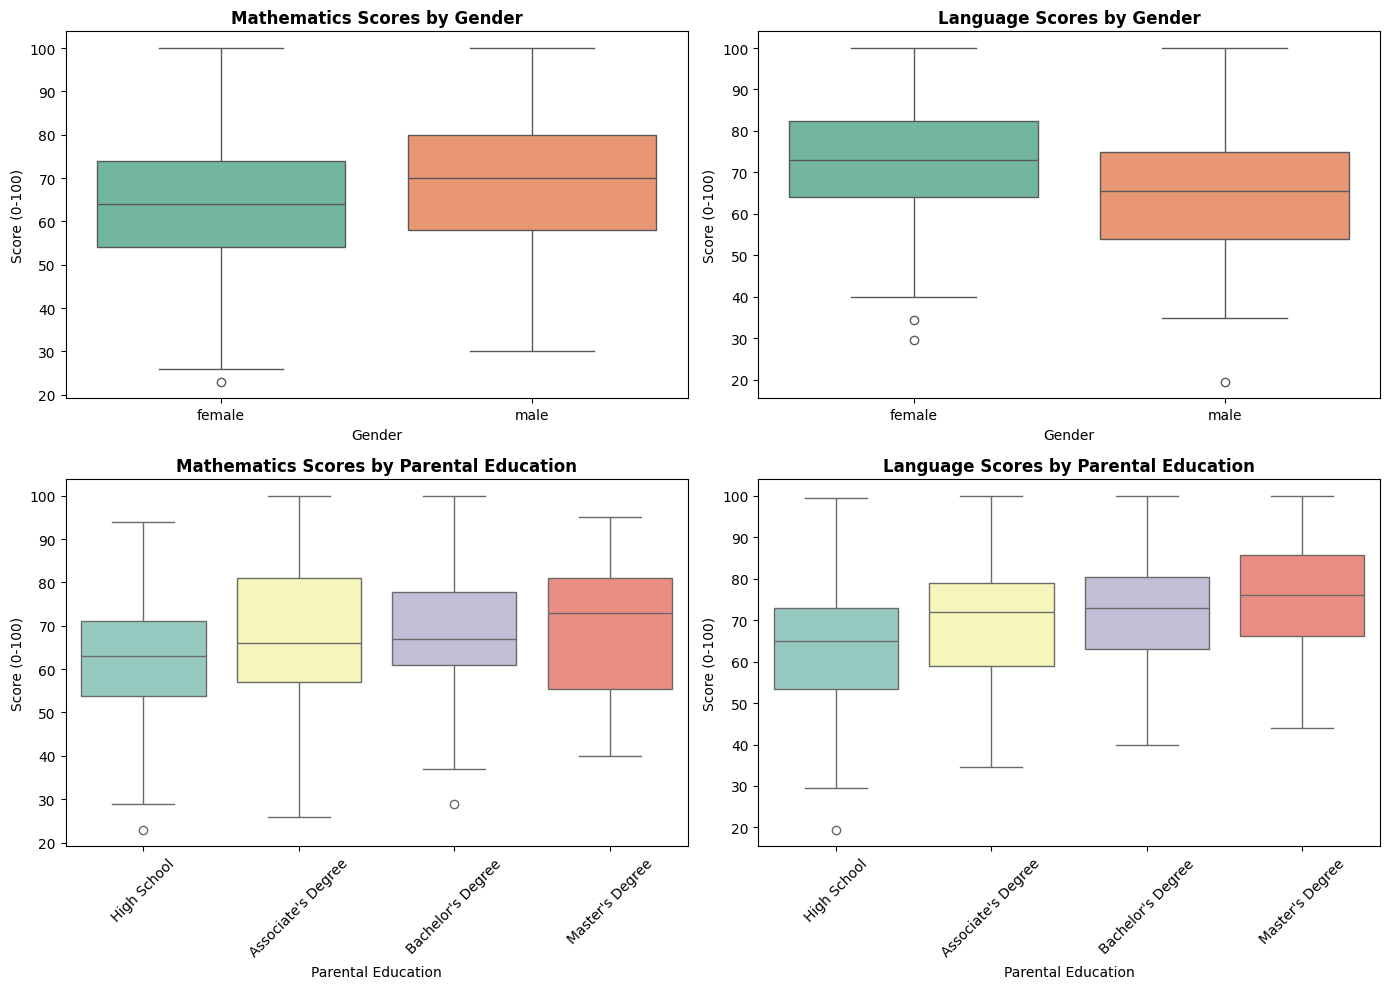


Visualization notes:
- Mathematics scores show group patterns
- Language scores show group patterns
- Outliers visible in some groups


In [11]:
print("\n" + "="*60)
print("STEP 4: EXPLORATORY VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=data, x='Gender', y='Mathematics', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Mathematics Scores by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Score (0-100)')

sns.boxplot(data=data, x='Gender', y='Language', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Language Scores by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score (0-100)')

sns.boxplot(data=data, x='ParentalEducation', y='Mathematics', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Mathematics Scores by Parental Education', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Score (0-100)')
axes[1, 0].set_xlabel('Parental Education')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=data, x='ParentalEducation', y='Language', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Language Scores by Parental Education', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Score (0-100)')
axes[1, 1].set_xlabel('Parental Education')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('scores_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization notes:")
print("- Mathematics scores show group patterns")
print("- Language scores show group patterns")
print("- Outliers visible in some groups")

In [12]:
print("\n" + "="*60)
print("STEP 5: ASSUMPTION CHECKS FOR PARAMETRIC TESTS")
print("="*60)

def check_normality_by_groups(data_col, group_col, data_df):
    print(f"\n--- Normality tests for {data_col} by {group_col} ---")
    groups = data_df[group_col].unique()
    for group in sorted(groups):
        subset = data_df[data_df[group_col] == group][data_col].dropna()
        if len(subset) > 3:
            stat, p_val = shapiro(subset)
            print(f"{group}: Shapiro-Wilk p={p_val:.4f} (n={len(subset)})")

print("\nMATHEMATICS NORMALITY:")
check_normality_by_groups('Mathematics', 'Gender', data)
check_normality_by_groups('Mathematics', 'ParentalEducation', data)

print("\nLANGUAGE NORMALITY:")
check_normality_by_groups('Language', 'Gender', data)
check_normality_by_groups('Language', 'ParentalEducation', data)

print("\n" + "="*60)
print("HOMOGENEITY OF VARIANCE (Levene's Test)")
print("="*60)

math_gender_groups = [data[data['Gender'] == g]['Mathematics'].dropna() for g in sorted(data['Gender'].unique())]
lang_gender_groups = [data[data['Gender'] == g]['Language'].dropna() for g in sorted(data['Gender'].unique())]

math_gender_levene = levene(*math_gender_groups)
lang_gender_levene = levene(*lang_gender_groups)

print(f"\nMathematics by Gender - Levene: stat={math_gender_levene.statistic:.4f}, p={math_gender_levene.pvalue:.4f}")
print(f"Language by Gender - Levene: stat={lang_gender_levene.statistic:.4f}, p={lang_gender_levene.pvalue:.4f}")

math_edu_groups = [data[data['ParentalEducation'] == e]['Mathematics'].dropna() 
                   for e in sorted(data['ParentalEducation'].unique())]
lang_edu_groups = [data[data['ParentalEducation'] == e]['Language'].dropna() 
                   for e in sorted(data['ParentalEducation'].unique())]

math_edu_levene = levene(*math_edu_groups)
lang_edu_levene = levene(*lang_edu_groups)

print(f"\nMathematics by ParentalEducation - Levene: stat={math_edu_levene.statistic:.4f}, p={math_edu_levene.pvalue:.4f}")
print(f"Language by ParentalEducation - Levene: stat={lang_edu_levene.statistic:.4f}, p={lang_edu_levene.pvalue:.4f}")

print("\nInterpretation: p > 0.05 suggests equal variances (parametric test appropriate)")


STEP 5: ASSUMPTION CHECKS FOR PARAMETRIC TESTS

MATHEMATICS NORMALITY:

--- Normality tests for Mathematics by Gender ---
female: Shapiro-Wilk p=0.5010 (n=245)
male: Shapiro-Wilk p=0.0505 (n=241)

--- Normality tests for Mathematics by ParentalEducation ---
Associate's Degree: Shapiro-Wilk p=0.0490 (n=177)
Bachelor's Degree: Shapiro-Wilk p=0.6086 (n=94)
High School: Shapiro-Wilk p=0.3692 (n=156)
Master's Degree: Shapiro-Wilk p=0.0317 (n=59)

LANGUAGE NORMALITY:

--- Normality tests for Language by Gender ---
female: Shapiro-Wilk p=0.0853 (n=245)
male: Shapiro-Wilk p=0.1390 (n=241)

--- Normality tests for Language by ParentalEducation ---
Associate's Degree: Shapiro-Wilk p=0.1202 (n=177)
Bachelor's Degree: Shapiro-Wilk p=0.4078 (n=94)
High School: Shapiro-Wilk p=0.2232 (n=156)
Master's Degree: Shapiro-Wilk p=0.5121 (n=59)

HOMOGENEITY OF VARIANCE (Levene's Test)

Mathematics by Gender - Levene: stat=0.0060, p=0.9382
Language by Gender - Levene: stat=0.1596, p=0.6897

Mathematics by Pa

In [13]:
print("\n" + "="*60)
print("STEP 6: HYPOTHESIS TESTS (α = 0.05)")
print("="*60)

test_results = []

print("\n\n--- GENDER EFFECTS ---\n")

print("1a. Mathematics by Gender")
math_by_gender = [data[data['Gender'] == g]['Mathematics'].dropna() for g in sorted(data['Gender'].unique())]
genders = sorted(data['Gender'].unique())

t_stat_math, p_val_math = stats.ttest_ind(math_by_gender[0], math_by_gender[1], equal_var=False)

mean_diff_math = math_by_gender[0].mean() - math_by_gender[1].mean()
pooled_std_math = np.sqrt(((len(math_by_gender[0])-1)*math_by_gender[0].std()**2 + 
                            (len(math_by_gender[1])-1)*math_by_gender[1].std()**2) / 
                           (len(math_by_gender[0]) + len(math_by_gender[1]) - 2))
cohens_d_math = mean_diff_math / pooled_std_math

print(f"Welch t-test: t={t_stat_math:.4f}, p={p_val_math:.4f}")
print(f"Mean {genders[0]}: {math_by_gender[0].mean():.2f}, Mean {genders[1]}: {math_by_gender[1].mean():.2f}")
print(f"Cohen's d: {cohens_d_math:.4f}")
sig_math_gender = "Yes" if p_val_math < 0.05 else "No"
print(f"Significant at α=0.05: {sig_math_gender}")
test_results.append({
    'Test': 'Welch t-test', 
    'Outcome': 'Mathematics', 
    'Grouping': 'Gender',
    'Statistic': f't={t_stat_math:.4f}',
    'p-value': f'{p_val_math:.4f}',
    'Effect Size': f"Cohen's d={cohens_d_math:.4f}",
    'Significant': sig_math_gender
})

print("\n1b. Language by Gender")
lang_by_gender = [data[data['Gender'] == g]['Language'].dropna() for g in sorted(data['Gender'].unique())]

t_stat_lang, p_val_lang = stats.ttest_ind(lang_by_gender[0], lang_by_gender[1], equal_var=False)

mean_diff_lang = lang_by_gender[0].mean() - lang_by_gender[1].mean()
pooled_std_lang = np.sqrt(((len(lang_by_gender[0])-1)*lang_by_gender[0].std()**2 + 
                            (len(lang_by_gender[1])-1)*lang_by_gender[1].std()**2) / 
                           (len(lang_by_gender[0]) + len(lang_by_gender[1]) - 2))
cohens_d_lang = mean_diff_lang / pooled_std_lang

print(f"Welch t-test: t={t_stat_lang:.4f}, p={p_val_lang:.4f}")
print(f"Mean {genders[0]}: {lang_by_gender[0].mean():.2f}, Mean {genders[1]}: {lang_by_gender[1].mean():.2f}")
print(f"Cohen's d: {cohens_d_lang:.4f}")
sig_lang_gender = "Yes" if p_val_lang < 0.05 else "No"
print(f"Significant at α=0.05: {sig_lang_gender}")
test_results.append({
    'Test': 'Welch t-test', 
    'Outcome': 'Language', 
    'Grouping': 'Gender',
    'Statistic': f't={t_stat_lang:.4f}',
    'p-value': f'{p_val_lang:.4f}',
    'Effect Size': f"Cohen's d={cohens_d_lang:.4f}",
    'Significant': sig_lang_gender
})

print("\n\n--- PARENTAL EDUCATION EFFECTS ---\n")

print("2a. Mathematics by Parental Education")
math_by_edu = [data[data['ParentalEducation'] == e]['Mathematics'].dropna() 
               for e in sorted(data['ParentalEducation'].unique())]
edu_cats = sorted(data['ParentalEducation'].unique())

from scipy.stats import f_oneway
f_stat_math_edu, p_val_math_edu = f_oneway(*math_by_edu)

grand_mean_math = data['Mathematics'].mean()
ss_between_math = sum(len(g) * (g.mean() - grand_mean_math)**2 for g in math_by_edu)
ss_total_math = sum((data['Mathematics'] - grand_mean_math)**2)
eta_sq_math = ss_between_math / ss_total_math

print(f"One-way ANOVA: F={f_stat_math_edu:.4f}, p={p_val_math_edu:.4f}")
print(f"η² (eta-squared): {eta_sq_math:.4f}")
for i, cat in enumerate(edu_cats):
    print(f"  Mean {cat}: {math_by_edu[i].mean():.2f}")
sig_math_edu = "Yes" if p_val_math_edu < 0.05 else "No"
print(f"Significant at α=0.05: {sig_math_edu}")
test_results.append({
    'Test': 'One-way ANOVA', 
    'Outcome': 'Mathematics', 
    'Grouping': 'Parental Education',
    'Statistic': f'F={f_stat_math_edu:.4f}',
    'p-value': f'{p_val_math_edu:.4f}',
    'Effect Size': f'η²={eta_sq_math:.4f}',
    'Significant': sig_math_edu
})

print("\n2b. Language by Parental Education")
lang_by_edu = [data[data['ParentalEducation'] == e]['Language'].dropna() 
               for e in sorted(data['ParentalEducation'].unique())]

f_stat_lang_edu, p_val_lang_edu = f_oneway(*lang_by_edu)

grand_mean_lang = data['Language'].mean()
ss_between_lang = sum(len(g) * (g.mean() - grand_mean_lang)**2 for g in lang_by_edu)
ss_total_lang = sum((data['Language'] - grand_mean_lang)**2)
eta_sq_lang = ss_between_lang / ss_total_lang

print(f"One-way ANOVA: F={f_stat_lang_edu:.4f}, p={p_val_lang_edu:.4f}")
print(f"η² (eta-squared): {eta_sq_lang:.4f}")
for i, cat in enumerate(edu_cats):
    print(f"  Mean {cat}: {lang_by_edu[i].mean():.2f}")
sig_lang_edu = "Yes" if p_val_lang_edu < 0.05 else "No"
print(f"Significant at α=0.05: {sig_lang_edu}")
test_results.append({
    'Test': 'One-way ANOVA', 
    'Outcome': 'Language', 
    'Grouping': 'Parental Education',
    'Statistic': f'F={f_stat_lang_edu:.4f}',
    'p-value': f'{p_val_lang_edu:.4f}',
    'Effect Size': f'η²={eta_sq_lang:.4f}',
    'Significant': sig_lang_edu
})

post_hoc_needed = {
    'math_edu': p_val_math_edu < 0.05,
    'lang_edu': p_val_lang_edu < 0.05
}


STEP 6: HYPOTHESIS TESTS (α = 0.05)


--- GENDER EFFECTS ---

1a. Mathematics by Gender
Welch t-test: t=-3.7782, p=0.0002
Mean female: 63.86, Mean male: 68.95
Cohen's d: -0.3426
Significant at α=0.05: Yes

1b. Language by Gender
Welch t-test: t=6.4096, p=0.0000
Mean female: 73.00, Mean male: 64.93
Cohen's d: 0.5814
Significant at α=0.05: Yes


--- PARENTAL EDUCATION EFFECTS ---

2a. Mathematics by Parental Education
One-way ANOVA: F=6.2229, p=0.0004
η² (eta-squared): 0.0373
  Mean Associate's Degree: 67.81
  Mean Bachelor's Degree: 68.44
  Mean High School: 62.24
  Mean Master's Degree: 69.75
Significant at α=0.05: Yes

2b. Language by Parental Education
One-way ANOVA: F=14.2406, p=0.0000
η² (eta-squared): 0.0814
  Mean Associate's Degree: 70.02
  Mean Bachelor's Degree: 72.06
  Mean High School: 63.53
  Mean Master's Degree: 75.53
Significant at α=0.05: Yes


In [14]:
print("\n" + "="*60)
print("STEP 7: POST-HOC COMPARISONS (if overall test significant)")
print("="*60)

from scipy.stats import ttest_ind

def pairwise_ttests_with_bonferroni(groups, group_labels, alpha=0.05):
    k = len(groups)
    n_comparisons = k * (k - 1) / 2
    bonferroni_alpha = alpha / n_comparisons
    
    results = []
    for i in range(k):
        for j in range(i+1, k):
            t_stat, p_val = ttest_ind(groups[i], groups[j], equal_var=True)
            mean_diff = groups[i].mean() - groups[j].mean()
            
            sig = "Yes" if p_val < bonferroni_alpha else "No"
            
            results.append({
                'Group 1': group_labels[i],
                'Group 2': group_labels[j],
                'Mean Diff': f'{mean_diff:.2f}',
                'p-value': f'{p_val:.4f}',
                'Sig (Bonf)': sig
            })
    return pd.DataFrame(results)

if post_hoc_needed['math_edu']:
    print("\nPost-hoc: Mathematics by Parental Education (Pairwise t-tests, Bonferroni corrected)")
    math_edu_labels = [str(e) for e in sorted(data['ParentalEducation'].unique())]
    posthoc_math_df = pairwise_ttests_with_bonferroni(math_by_edu, math_edu_labels)
    print(posthoc_math_df.to_string(index=False))
else:
    print("\nPost-hoc: Mathematics by Parental Education - NOT NEEDED (p > 0.05)")

if post_hoc_needed['lang_edu']:
    print("\nPost-hoc: Language by Parental Education (Pairwise t-tests, Bonferroni corrected)")
    lang_edu_labels = [str(e) for e in sorted(data['ParentalEducation'].unique())]
    posthoc_lang_df = pairwise_ttests_with_bonferroni(lang_by_edu, lang_edu_labels)
    print(posthoc_lang_df.to_string(index=False))
else:
    print("\nPost-hoc: Language by Parental Education - NOT NEEDED (p > 0.05)")


STEP 7: POST-HOC COMPARISONS (if overall test significant)

Post-hoc: Mathematics by Parental Education (Pairwise t-tests, Bonferroni corrected)
           Group 1           Group 2 Mean Diff p-value Sig (Bonf)
Associate's Degree Bachelor's Degree     -0.62  0.7481         No
Associate's Degree       High School      5.57  0.0006        Yes
Associate's Degree   Master's Degree     -1.93  0.3993         No
 Bachelor's Degree       High School      6.19  0.0012        Yes
 Bachelor's Degree   Master's Degree     -1.31  0.6021         No
       High School   Master's Degree     -7.50  0.0007        Yes

Post-hoc: Language by Parental Education (Pairwise t-tests, Bonferroni corrected)
           Group 1           Group 2 Mean Diff p-value Sig (Bonf)
Associate's Degree Bachelor's Degree     -2.04  0.2634         No
Associate's Degree       High School      6.49  0.0000        Yes
Associate's Degree   Master's Degree     -5.50  0.0098         No
 Bachelor's Degree       High School      8.5

In [15]:
print("\n" + "="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

print("\n📊 KEY FINDINGS:\n")

print(f"1. Gender → Mathematics:")
print(f"   • Significant: {sig_math_gender}")
if sig_math_gender == "Yes":
    direction = "higher" if mean_diff_math > 0 else "lower"
    print(f"   • {genders[0]} students score {direction} ({mean_diff_math:.2f} points)")
else:
    print(f"   • No significant difference between genders")
print(f"   • Effect size (Cohen's d): {cohens_d_math:.4f}")

print(f"\n2. Gender → Language:")
print(f"   • Significant: {sig_lang_gender}")
if sig_lang_gender == "Yes":
    direction = "higher" if mean_diff_lang > 0 else "lower"
    print(f"   • {genders[0]} students score {direction} ({mean_diff_lang:.2f} points)")
else:
    print(f"   • No significant difference between genders")
print(f"   • Effect size (Cohen's d): {cohens_d_lang:.4f}")

print(f"\n3. Parental Education → Mathematics:")
print(f"   • Significant: {sig_math_edu}")
print(f"   • Effect size (η²): {eta_sq_math:.4f}")

print(f"\n4. Parental Education → Language:")
print(f"   • Significant: {sig_lang_edu}")
print(f"   • Effect size (η²): {eta_sq_lang:.4f}")

print("\n" + "="*70)
print("RESULTS TABLE")
print("="*70)
results_df = pd.DataFrame(test_results)
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS - OVERALL")
print("="*70)
print(data[['Mathematics', 'Language']].describe().round(2))

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS - BY GENDER")
print("="*70)
by_gender = data.groupby('Gender')[['Mathematics', 'Language']].describe().round(2)
print(by_gender)

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS - BY PARENTAL EDUCATION")
print("="*70)
by_edu = data.groupby('ParentalEducation')[['Mathematics', 'Language']].describe().round(2)
print(by_edu)

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)


EXECUTIVE SUMMARY

📊 KEY FINDINGS:

1. Gender → Mathematics:
   • Significant: Yes
   • female students score lower (-5.09 points)
   • Effect size (Cohen's d): -0.3426

2. Gender → Language:
   • Significant: Yes
   • female students score higher (8.07 points)
   • Effect size (Cohen's d): 0.5814

3. Parental Education → Mathematics:
   • Significant: Yes
   • Effect size (η²): 0.0373

4. Parental Education → Language:
   • Significant: Yes
   • Effect size (η²): 0.0814

RESULTS TABLE
         Test     Outcome           Grouping Statistic p-value       Effect Size Significant
 Welch t-test Mathematics             Gender t=-3.7782  0.0002 Cohen's d=-0.3426         Yes
 Welch t-test    Language             Gender  t=6.4096  0.0000  Cohen's d=0.5814         Yes
One-way ANOVA Mathematics Parental Education  F=6.2229  0.0004         η²=0.0373         Yes
One-way ANOVA    Language Parental Education F=14.2406  0.0000         η²=0.0814         Yes

DESCRIPTIVE STATISTICS - OVERALL
subject  